# LLM Fingerprints

Stylometric and association-rule analysis of ChatGPT, Gemini, and Claude responses from the lmsys/chatbot_arena_conversations dataset.

In [ ]:
import re
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "requirements.txt").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

random.seed(42)
np.random.seed(42)

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [ ]:
DATA_PATH = next((PROJECT_ROOT / "src" / "dataset").glob("*.parquet"))
print("Using dataset:", DATA_PATH)

Using dataset: /Users/haydenleung/SCU/LLM-Fingerprints/src/dataset/train-00000-of-00001-cced8514c7ed782a(1).parquet


## Phase 1.1 - Dataset Extraction

Load the dataset, filter to ChatGPT / Gemini / Claude model labels, and group the assistant response text into three corpuses.

In [37]:
df = pd.read_parquet(DATA_PATH)

In [38]:
LABELS = {
    "ChatGPT": ["gpt"],
    "Claude": ["claude"],
    "Gemini": ["gemini", "bard", "palm"],  # Google since dataset predates Gemini
}


def classify(model_name):
    m = str(model_name).lower()
    for label, keys in LABELS.items():
        if any(k in m for k in keys):
            return label
    return None


def assistant_text(conversation):
    parts = [t["content"] for t in conversation if t.get("role") == "assistant"]
    return " ".join(parts).strip()


corpus = {"ChatGPT": [], "Claude": [], "Gemini": []}
for _, row in df.iterrows():
    for model_col, conv_col in [("model_a", "conversation_a"), ("model_b", "conversation_b")]:
        label = classify(row[model_col])
        if label is None:
            continue
        text = assistant_text(row[conv_col])
        if text:
            corpus[label].append(text)

for model, texts in corpus.items():
    print(f"{model}: {len(texts)} responses")

ChatGPT: 9967 responses
Claude: 6553 responses
Gemini: 2955 responses


In [ ]:
# Balance all corpuses to the smallest one so each model has the same number of responses (fair comparison for both tracks).
MAX_PER_MODEL = min(len(texts) for texts in corpus.values())
for model in corpus:
    corpus[model] = random.sample(corpus[model], MAX_PER_MODEL)

{model: len(texts) for model, texts in corpus.items()}

{'ChatGPT': 2955, 'Claude': 2955, 'Gemini': 2955}

## Phase 1.2 - Dual-Track Preprocessing

**Track A (Stylometrics)**: the raw text is kept exactly as generated.
**Track B (Association Mining)**: lowercase, tokenize, drop standard stop words, but keep stylistic transition words.

In [40]:
STOP = set(stopwords.words("english"))

# Stylistic transition words we explicitly retain despite being stop words.
KEEP = {
    "however", "firstly", "secondly", "thirdly", "moreover", "furthermore",
    "additionally", "therefore", "thus", "delve", "crucial", "nuanced",
    "overall", "essentially", "notably", "ultimately",
}
STOP = STOP - KEEP


def track_b_tokens(text):
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in STOP]


tokens_by_model = {
    model: [track_b_tokens(t) for t in texts] for model, texts in corpus.items()
}

## Phase 2 - Computing Stylometrics

Aggregate structural statistics per corpus: sentence length mean/variance, type-token ratio, and markdown / punctuation density per 1,000 words.

In [41]:
def stylometrics(texts):
    sentence_lengths = []
    all_tokens = []
    bullets = bold = code = colon = semicolon = emdash = 0

    for t in texts:
        for sentence in sent_tokenize(t):
            words = [w for w in word_tokenize(sentence) if w.isalpha()]
            if words:
                sentence_lengths.append(len(words))

        all_tokens.extend(w.lower() for w in word_tokenize(t) if w.isalpha())

        bullets += len(re.findall(r"(?m)^\s*[\*\-]\s", t))
        bold += t.count("**") // 2
        code += t.count("```") // 2
        colon += t.count(":")
        semicolon += t.count(";")
        emdash += t.count("\u2014") + t.count("--")

    total_words = len(all_tokens)
    unique_words = len(set(all_tokens))

    def per_1k(count):
        return 1000 * count / total_words if total_words else 0.0

    return {
        "responses": len(texts),
        "avg_sentence_len": float(np.mean(sentence_lengths)) if sentence_lengths else 0.0,
        "sentence_len_var": float(np.var(sentence_lengths)) if sentence_lengths else 0.0,
        "ttr": unique_words / total_words if total_words else 0.0,
        "bullets_per_1k": per_1k(bullets),
        "bold_per_1k": per_1k(bold),
        "code_per_1k": per_1k(code),
        "colon_per_1k": per_1k(colon),
        "semicolon_per_1k": per_1k(semicolon),
        "emdash_per_1k": per_1k(emdash),
    }


stats = {model: stylometrics(texts) for model, texts in corpus.items()}
stats_df = pd.DataFrame(stats).T
stats_df

,responses,avg_sentence_len,sentence_len_var,ttr,bullets_per_1k,bold_per_1k,code_per_1k,colon_per_1k,semicolon_per_1k,emdash_per_1k
ChatGPT,2955.0,17.401585,173.543242,0.077988,4.611039,0.142505,1.045881,20.080413,2.890806,0.712523
Claude,2955.0,14.546508,145.482141,0.078294,6.187506,0.090703,0.899140,17.866474,2.340526,1.127869
Gemini,2955.0,15.423918,114.022514,0.038382,11.979418,4.476839,1.121661,13.046172,1.766812,0.770652


## Phase 3 - Association Rule Mining

Treat each response as a transaction and its unique words as items. Run Apriori per model and keep rules that pass support, confidence, and lift thresholds.

In [42]:
def mine_rules(token_lists, top_vocab=150, min_support=0.02, min_conf=0.3, min_lift=1.0):
    freq = Counter()
    for toks in token_lists:
        freq.update(set(toks))
    vocab = {w for w, _ in freq.most_common(top_vocab)}

    transactions = [sorted(set(toks) & vocab) for toks in token_lists]
    transactions = [t for t in transactions if t]

    te = TransactionEncoder()
    onehot = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

    frequent = apriori(onehot, min_support=min_support, use_colnames=True)
    rules = association_rules(frequent, metric="lift", min_threshold=min_lift)
    rules = rules[(rules["confidence"] >= min_conf) & (rules["support"] >= min_support)]
    return rules.sort_values("lift", ascending=False).reset_index(drop=True)


rules_by_model = {model: mine_rules(tokens_by_model[model]) for model in corpus}
for model, rules in rules_by_model.items():
    print(f"{model}: {len(rules)} rules")

ChatGPT: 263 rules
Claude: 10245 rules
Gemini: 77468 rules


In [43]:
def show_rules(rules, n=10):
    out = rules.head(n).copy()
    out["antecedents"] = out["antecedents"].apply(lambda s: ", ".join(s))
    out["consequents"] = out["consequents"].apply(lambda s: ", ".join(s))
    return out[["antecedents", "consequents", "support", "confidence", "lift"]]

for model, rules in rules_by_model.items():
    print(f"\n{model}")
    display(show_rules(rules))


ChatGPT


,antecedents,consequents,support,confidence,lift
0,"ai, language","however, model",0.030775,0.484663,13.235413
1,"however, model","ai, language",0.030775,0.840426,13.235413
2,"ai, language","model, provide",0.032333,0.509202,12.814928
3,"model, provide","ai, language",0.032333,0.813725,12.814928
4,"language, provide","ai, model",0.032333,0.783019,12.721579
5,"ai, model","language, provide",0.032333,0.525316,12.721579
6,"however, language","ai, model",0.030775,0.782178,12.707921
7,"ai, model","however, language",0.030775,0.500000,12.707921
8,"ai, model","language, information",0.021815,0.354430,12.636428
9,"language, information","ai, model",0.021815,0.777778,12.636428



Claude


,antecedents,consequents,support,confidence,lift
0,"like, questions, helps, know","let, hope, summary",0.020874,0.407692,8.847272
1,"like, questions, helps","let, hope, summary, know",0.020874,0.407692,8.847272
2,"let, hope, summary","like, questions, helps, know",0.020874,0.452991,8.847272
3,"let, hope, summary","like, questions, helps",0.020874,0.452991,8.847272
4,"hope, summary, know","let, like, questions, helps",0.020874,0.452991,8.847272
5,"like, questions, helps","let, hope, summary",0.020874,0.407692,8.847272
6,"hope, summary, know","like, questions, helps",0.020874,0.452991,8.847272
7,"let, hope, summary, know","like, questions, helps",0.020874,0.452991,8.847272
8,"let, like, questions, helps","hope, summary, know",0.020874,0.407692,8.847272
9,"like, questions, helps","hope, summary, know",0.020874,0.407692,8.847272



Gemini


,antecedents,consequents,support,confidence,lift
0,"hope, know","let, questions",0.020716,0.648352,26.007120
1,"let, questions","hope, know",0.020716,0.830986,26.007120
2,"let, hope","questions, know",0.020716,0.719512,25.938870
3,"questions, know","let, hope",0.020716,0.746835,25.938870
4,"hope, questions","let, know",0.020716,0.719512,18.628825
5,"let, know","hope, questions",0.020716,0.536364,18.628825
6,"also, range",wide,0.023876,0.739130,16.976157
7,wide,"also, range",0.023876,0.548387,16.976157
8,"us, able, send, feedback","model, language, please, error",0.061447,1.000000,16.274286
9,"us, language, able, error","model, please, send, feedback",0.061447,1.000000,16.274286


## Phase 4 - Synthesis & Visualization

### Stylometric radar chart

In [44]:
metrics = ["ttr", "sentence_len_var", "markdown_density", "punctuation_density"]
radar = pd.DataFrame(index=list(corpus.keys()), columns=metrics, dtype=float)

for model in corpus:
    s = stats[model]
    radar.loc[model, "ttr"] = s["ttr"]
    radar.loc[model, "sentence_len_var"] = s["sentence_len_var"]
    radar.loc[model, "markdown_density"] = s["bullets_per_1k"] + s["bold_per_1k"] + s["code_per_1k"]
    radar.loc[model, "punctuation_density"] = s["colon_per_1k"] + s["semicolon_per_1k"] + s["emdash_per_1k"]

#normalize each metric to [0, 1]
norm = (radar - radar.min()) / (radar.max() - radar.min())
norm = norm.fillna(0.0)
norm

,ttr,sentence_len_var,markdown_density,punctuation_density
ChatGPT,0.992331,1.000000,0.000000,1.000000
Claude,1.000000,0.528549,0.116986,0.710019
Gemini,0.000000,0.000000,1.000000,0.000000


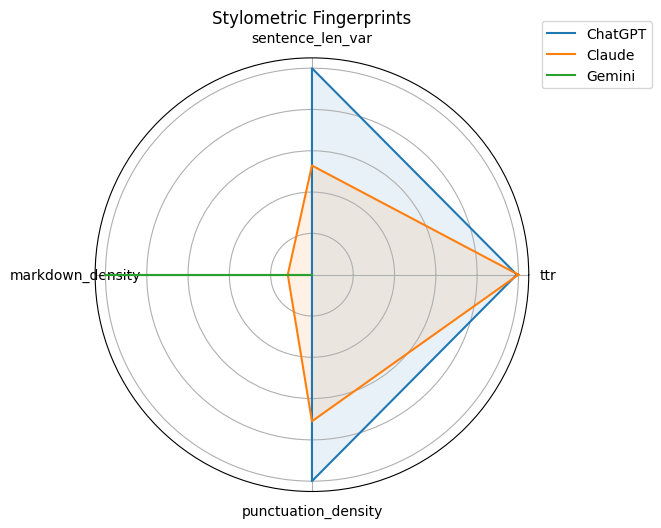

In [45]:
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
for model in norm.index:
    values = norm.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_yticklabels([])
ax.set_title("Stylometric Fingerprints")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIG_DIR / "stylometric_radar.png", dpi=150)
plt.show()

### Association networks
Top 20 highest-lift rules per model as a directed graph.

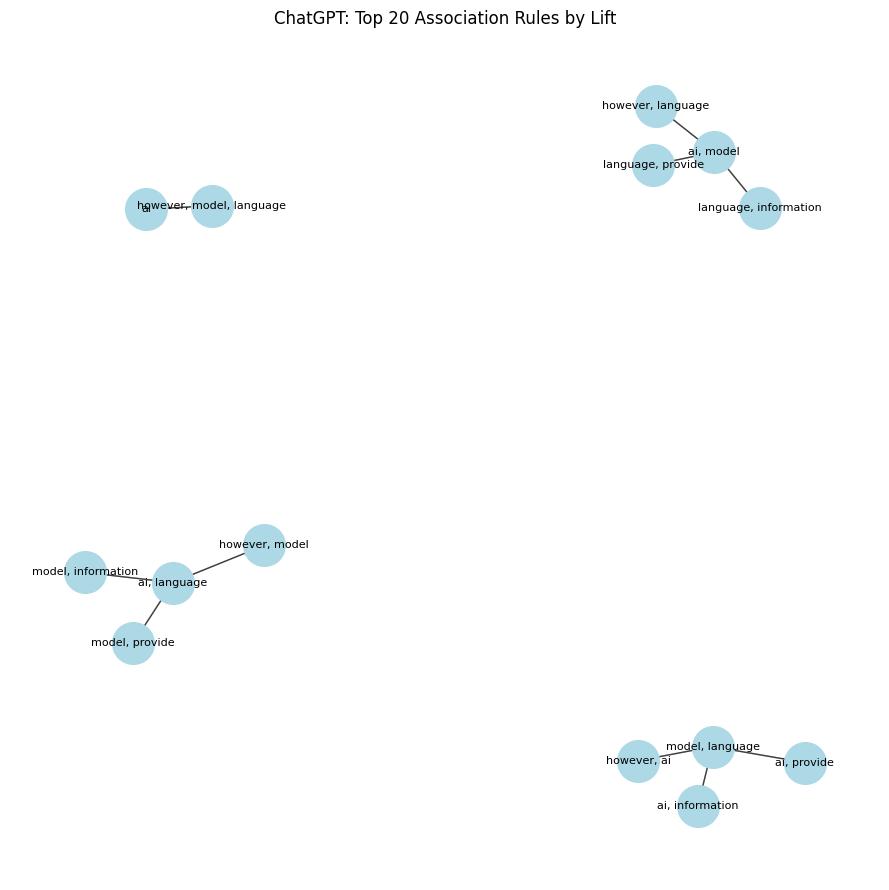

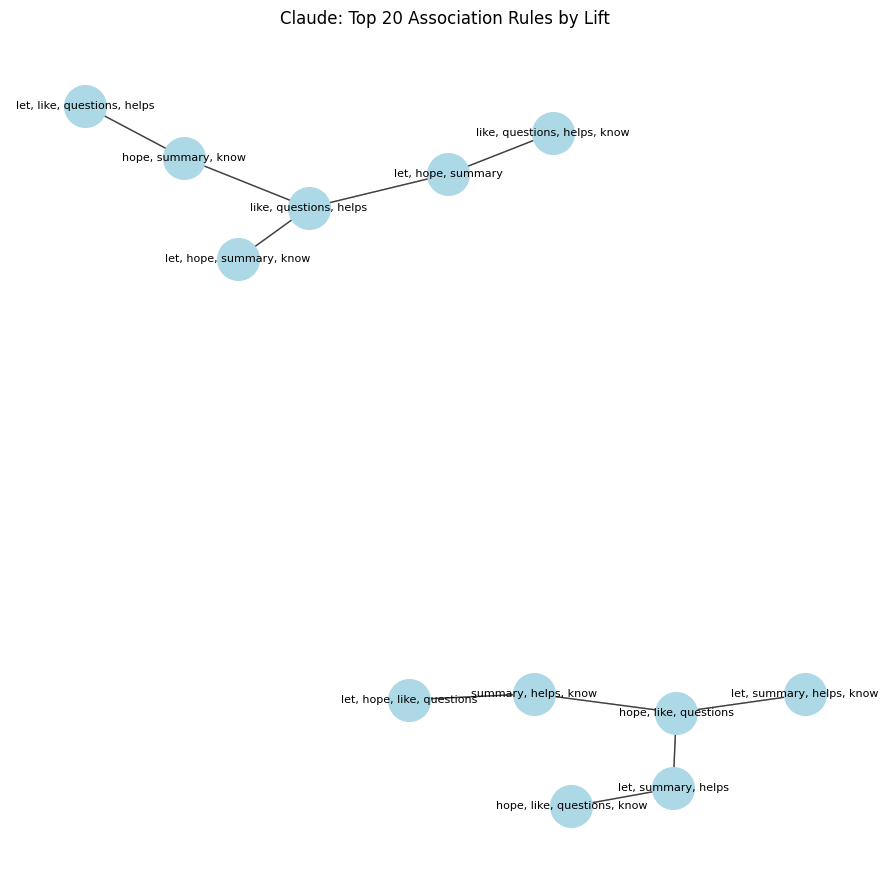

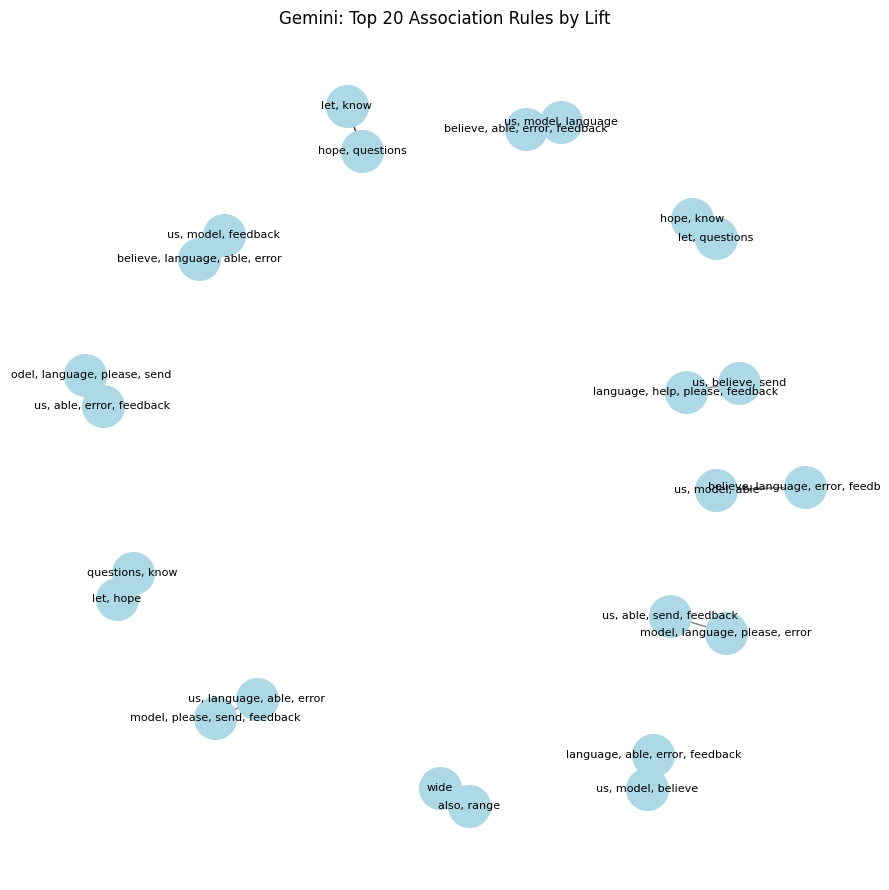

In [46]:
def plot_network(rules, model, filename):
    top = rules.head(20)
    G = nx.DiGraph()
    for _, r in top.iterrows():
        a = ", ".join(r["antecedents"])
        c = ", ".join(r["consequents"])
        G.add_edge(a, c, weight=float(r["lift"]))

    fig, ax = plt.subplots(figsize=(9, 9))
    if len(G) == 0:
        ax.text(0.5, 0.5, "No rules passed the thresholds", ha="center")
        ax.axis("off")
    else:
        pos = nx.spring_layout(G, seed=42, k=0.7)
        nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=900, ax=ax)
        nx.draw_networkx_edges(G, pos, arrows=True, ax=ax, alpha=0.5)
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
        ax.set_title(f"{model}: Top {len(top)} Association Rules by Lift")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=150)
    plt.show()


plot_network(rules_by_model["ChatGPT"], "ChatGPT", "association_network_chatgpt.png")
plot_network(rules_by_model["Claude"], "Claude", "association_network_claude.png")
plot_network(rules_by_model["Gemini"], "Gemini", "association_network_gemini.png")

# Phase 5: Prediction Modelling (LLM Classifier)

**Semantics Across AI Models**

In [ ]:
TOP_N_RULES = 60   # taken across N rules of models


def extract_cross_model_vocab(
    rules_by_model: dict[str, pd.DataFrame],
    n: int = TOP_N_RULES,
) -> list[str]:
    frames = []
    for model, rules in rules_by_model.items():
        if not rules.empty:
            tmp = rules.copy()
            tmp["source_model"] = model
            frames.append(tmp)

    pooled = (
        pd.concat(frames, ignore_index=True)
        .sort_values("lift", ascending=False)
        .head(n)
    )

    print(f"Top {n} rules by lift — source breakdown:")
    print(pooled["source_model"].value_counts().to_string(), "\n")

    vocab: set[str] = set()
    for col in ("antecedents", "consequents"):
        for itemset in pooled[col]:
            for item in itemset:
                for tok in item.split():
                    vocab.add(tok.lower())

    print(f"Unique signature tokens from top-{n} rules: {len(vocab)}")
    print(sorted(vocab))
    return sorted(vocab)
cross_model_vocab = extract_cross_model_vocab(rules_by_model, n=TOP_N_RULES)



Top 60 rules by lift — source breakdown:
source_model
Gemini    60 

Unique signature tokens from top-60 rules: 17
['able', 'also', 'believe', 'error', 'feedback', 'help', 'hope', 'know', 'language', 'let', 'model', 'please', 'questions', 'range', 'send', 'us', 'wide']


**Stylometric Featuring**

In [ ]:
def stylometrics_single(text: str) -> dict:
    return stylometrics([text])


def semantic_features_single(
    text: str,
    vocab: list[str],
) -> dict[str, float]:
    tokens     = track_b_tokens(text)
    total      = len(tokens)
    tok_counts = Counter(tokens)

    return {
        f"sem_{tok}": 1_000 * tok_counts.get(tok, 0) / total if total else 0.0
        for tok in vocab
    }


def build_per_response_matrix(
    corpus: dict[str, list[str]],
    vocab: list[str],
) -> pd.DataFrame: # freq per 1000 words
    records = []
    for label, texts in corpus.items():
        for text in texts:
            row: dict = {"label": label}

            s = stylometrics_single(text)

            # stylometric vars
            row["ttr"]                 = s["ttr"]
            row["sentence_len_var"]    = s["sentence_len_var"]
            row["markdown_density"]    = (s["bullets_per_1k"]
                                          + s["bold_per_1k"]
                                          + s["code_per_1k"])
            row["punctuation_density"] = (s["colon_per_1k"]
                                          + s["semicolon_per_1k"]
                                          + s["emdash_per_1k"])

            # features across models, vocabulary
            row.update(semantic_features_single(text, vocab))

            records.append(row)

    df = pd.DataFrame(records)
    df["label"] = df["label"].astype("category")
    return df


response_df = build_per_response_matrix(corpus, cross_model_vocab)

In [ ]:
STYLOMETRIC_COLS = [
    "ttr",
    "sentence_len_var",
    "markdown_density",
    "punctuation_density",
]

SEM_TOKEN_COLS   = [c for c in response_df.columns if c.startswith("sem_")]
ALL_FEATURE_COLS = STYLOMETRIC_COLS + SEM_TOKEN_COLS

print(f"Responses (rows)     : {len(response_df)}")
print(f"Stylometric features : {len(STYLOMETRIC_COLS)}")
print(f"Semantic features    : {len(SEM_TOKEN_COLS)}")
print(f"Total features       : {len(ALL_FEATURE_COLS)}")
display(response_df[["label"] + STYLOMETRIC_COLS].head(6))

Responses (rows)     : 8865
Stylometric features : 4
Semantic features    : 17
Total features       : 21


,label,ttr,sentence_len_var,markdown_density,punctuation_density
0,ChatGPT,0.433566,20.661626,0.000000,25.641026
1,ChatGPT,0.505882,21.984375,0.000000,35.294118
2,ChatGPT,0.636364,0.000000,166.666667,60.606061
3,ChatGPT,0.480620,36.071006,0.000000,15.503876
4,ChatGPT,1.000000,0.000000,0.000000,0.000000
5,ChatGPT,0.515723,19.358025,0.000000,81.761006


**Model Selection and Trainig**: Using Random Forest and splitting 80/20 train test

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = response_df[ALL_FEATURE_COLS]
y = response_df["label"]

# 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = 42,
)

print(f"Train : {len(X_train):,} responses")
print(f"Test  : {len(X_test):,} responses")
print("\nClass distribution — train:", y_train.value_counts().to_dict())
print("Class distribution — test: ", y_test.value_counts().to_dict())

Train : 7,092 responses
Test  : 1,773 responses

Class distribution — train: {'ChatGPT': 2364, 'Claude': 2364, 'Gemini': 2364}
Class distribution — test:  {'ChatGPT': 591, 'Claude': 591, 'Gemini': 591}


In [ ]:
#Random Forest handles the mix of continuous stylometric
clf = RandomForestClassifier(
    n_estimators     = 300,
    min_samples_leaf = 2,
    class_weight     = "balanced",
    oob_score        = True,
    n_jobs           = -1,
    random_state     = 42,
)
clf.fit(X_train, y_train)
print(f"OOB accuracy : {clf.oob_score_ * 100:.2f}%")

OOB accuracy : 67.74%
OOB accuracy : 64.58%
